# Problem Set 7

Solutions to Computational Problems

## Problem 1

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
raw_data = pd.read_stata("data/LM2007.dta")

CUTOFF = 59.1984
BANDWIDTH = 19.6

In [40]:
def clean_data(data):
    new_data = pd.DataFrame()
    new_data["state"] = data["state"].astype(int)
    new_data["poverty_rate"] = data["povrate60"]
    new_data["mortality_rate"] = data["mort_age59_related_postHS"]
    return new_data.query("mortality_rate < 80")

In [41]:
data = clean_data(raw_data)

Text(0.5, 0, 'Poverty Rate')

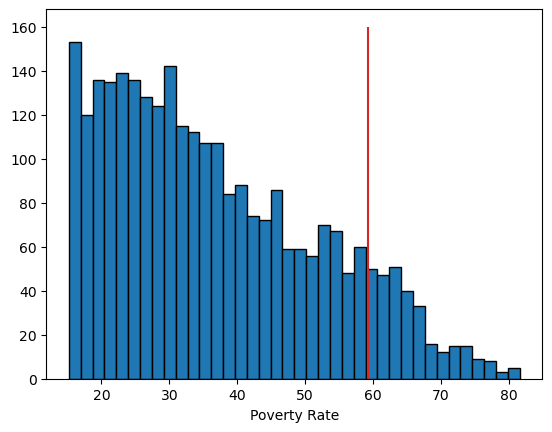

In [42]:
plt.hist(data["poverty_rate"], bins=38, ec="black", color="tab:blue")
plt.vlines(CUTOFF, 0, 160, colors="tab:red")
plt.xlabel("Poverty Rate")

In [44]:
def triangular_kernel(u):
    return np.clip(1 - np.abs(u), 0, 1)


def _local_linear_mean_estimate(
    new_x: float,
    data_x: np.ndarray | pd.Series,
    data_y: np.ndarray | pd.Series,
    cutoff: float = CUTOFF,
    kernel: callable = triangular_kernel,
    bandwidth: float = BANDWIDTH,
) -> float:

    if not isinstance(data_x, np.ndarray):
        data_x = np.array(data_x)
    if not isinstance(data_y, np.ndarray):
        data_y = np.array(data_y)

    below_cutoff = data_x < cutoff
    above_cutoff = data_x >= cutoff

    z = np.column_stack((np.ones_like(data_x), data_x - new_x))
    k = kernel((data_x - new_x) / bandwidth)

    k_zz = (k.reshape(-1, 1, 1) * z.reshape(-1, 2, 1)) @ z.reshape(-1, 1, 2)
    k_zy = k.reshape(-1, 1) * data_y.reshape(-1, 1) * z

    k_zz_0_inv = np.linalg.pinv(k_zz[below_cutoff].sum(axis=0))
    k_zz_1_inv = np.linalg.pinv(k_zz[above_cutoff].sum(axis=0))

    beta_hat_0 = k_zz_0_inv @ k_zy[below_cutoff].sum(axis=0)
    beta_hat_1 = k_zz_1_inv @ k_zy[above_cutoff].sum(axis=0)

    return beta_hat_0, beta_hat_1


def _calculate_leave_one_out_residuals(
    data_x: np.ndarray,
    data_y: np.ndarray,
    cutoff: float = CUTOFF,
    kernel: callable = triangular_kernel,
    bandwidth: float = BANDWIDTH,
) -> np.ndarray:

    if not isinstance(data_x, np.ndarray):
        data_x = np.array(data_x)
    if not isinstance(data_y, np.ndarray):
        data_y = np.array(data_y)

    errors = []
    for i in range(len(data_x)):

        x_i = data_x[i]

        beta_hat_0, beta_hat_1 = _local_linear_mean_estimate(
            new_x=x_i,
            data_x=np.delete(data_x, i),
            data_y=np.delete(data_y, i),
            cutoff=cutoff,
            kernel=kernel,
            bandwidth=bandwidth,
        )

        m_hat = beta_hat_0[0] * (x_i < cutoff) + beta_hat_1[0] * (x_i >= cutoff)
        e_i = data_y[i] - m_hat
        errors.append(e_i)

    return np.array(errors)


def _local_linear_mean_estimate_sd(
    new_x: float,
    data_x: np.ndarray,
    data_y: np.ndarray,
    cutoff: float = CUTOFF,
    kernel: callable = triangular_kernel,
    bandwidth: float = BANDWIDTH,
) -> float:

    if not isinstance(data_x, np.ndarray):
        data_x = np.array(data_x)
    if not isinstance(data_y, np.ndarray):
        data_y = np.array(data_y)

    e = _calculate_leave_one_out_residuals(
        data_x=data_x,
        data_y=data_y,
        cutoff=cutoff,
        kernel=kernel,
        bandwidth=bandwidth,
    )

    below_cutoff = data_x < cutoff
    above_cutoff = data_x >= cutoff

    z = np.column_stack((np.ones_like(data_x), data_x - new_x))
    k = kernel((data_x - new_x) / bandwidth)

    k_zz = (k.reshape(-1, 1, 1) * z.reshape(-1, 2, 1)) @ z.reshape(-1, 1, 2)

    k_zz_0_inv = np.linalg.pinv(k_zz[below_cutoff].sum(axis=0))
    k_zz_1_inv = np.linalg.pinv(k_zz[above_cutoff].sum(axis=0))

    k_sqrd_zz_e_sqrd = (
        ((k * e) ** 2).reshape(-1, 1, 1) * z.reshape(-1, 2, 1)
    ) @ z.reshape(-1, 1, 2)

    v_hat_0 = k_zz_0_inv @ k_sqrd_zz_e_sqrd[below_cutoff].sum(axis=0) @ k_zz_0_inv
    v_hat_1 = k_zz_1_inv @ k_sqrd_zz_e_sqrd[above_cutoff].sum(axis=0) @ k_zz_1_inv

    return np.sqrt(v_hat_0[0, 0] + v_hat_1[0, 0])


def local_linear_estimator(
    new_x: float,
    data_x: np.ndarray,
    data_y: np.ndarray,
    cutoff: float = CUTOFF,
    kernel: callable = triangular_kernel,
    bandwidth: float = BANDWIDTH,
) -> float:

    if not isinstance(data_x, np.ndarray):
        data_x = np.array(data_x)
    if not isinstance(data_y, np.ndarray):
        data_y = np.array(data_y)

    beta_hat_0, beta_hat_1 = _local_linear_mean_estimate(
        new_x=new_x,
        data_x=data_x,
        data_y=data_y,
        cutoff=cutoff,
        kernel=kernel,
        bandwidth=bandwidth,
    )

    sd = _local_linear_mean_estimate_sd(
        new_x=new_x,
        data_x=data_x,
        data_y=data_y,
        cutoff=cutoff,
        kernel=kernel,
        bandwidth=bandwidth,
    )

    return {
        "mean": beta_hat_0[0] * (new_x < cutoff) + beta_hat_1[0] * (new_x >= cutoff),
        "sd": sd,
    }

In [48]:
x_grid_below = np.arange(15, CUTOFF)
x_grid_above = np.arange(CUTOFF, 81)

means_below = np.empty_like(x_grid_below, dtype=float)
sds_below = np.empty_like(x_grid_below, dtype=float)

mean_above = np.empty_like(x_grid_above, dtype=float)
sds_above = np.empty_like(x_grid_above, dtype=float)

for i, x in enumerate(x_grid_below):
    result = local_linear_estimator(
        x,
        data["poverty_rate"],
        data["mortality_rate"],
        bandwidth=10,
    )
    means_below[i] = result["mean"]
    sds_below[i] = result["sd"]

for i, x in enumerate(x_grid_above):
    result = local_linear_estimator(
        x,
        data["poverty_rate"],
        data["mortality_rate"],
        bandwidth=10,
    )
    mean_above[i] = result["mean"]
    sds_above[i] = result["sd"]

Text(0, 0.5, 'Mortality Rate')

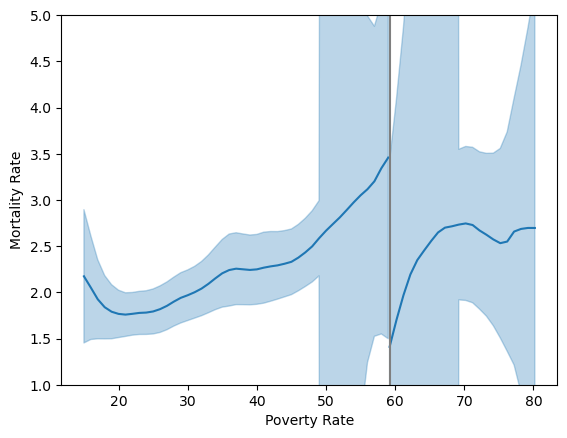

In [50]:
plt.plot(x_grid_below, means_below, color="tab:blue")
plt.plot(x_grid_above, mean_above, color="tab:blue")
plt.fill_between(
    x_grid_below,
    means_below - 2 * sds_below,
    means_below + 2 * sds_below,
    alpha=0.3,
    color="tab:blue",
)
plt.fill_between(
    x_grid_above,
    mean_above - 2 * sds_above,
    mean_above + 2 * sds_above,
    alpha=0.3,
    color="tab:blue",
)
plt.ylim(1, 5)
plt.vlines(CUTOFF, 1, 5, colors="tab:grey")
plt.xlabel("Poverty Rate")
plt.ylabel("Mortality Rate")
# plt.plot(data["poverty_rate"], data["mortality_rate"], "o", color="tab:grey", alpha=0.2)